In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer # Used for handling missing values

house = pd.read_csv('housing.csv')

X = house.drop('median_house_value', axis=1)
y = house.median_house_value

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=121)



In [2]:
X_train.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        170
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [3]:
X_test.isna().sum()


longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms        37
population             0
households             0
median_income          0
ocean_proximity        0
dtype: int64

In [4]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
5800,-118.24,34.15,7.0,2063.0,670.0,1892.0,643.0,1.7301,<1H OCEAN
601,-122.08,37.70,25.0,3402.0,758.0,1645.0,710.0,3.4934,NEAR BAY
10379,-117.64,33.65,4.0,6842.0,1512.0,3256.0,1439.0,5.4132,<1H OCEAN
20405,-118.88,34.21,26.0,1590.0,196.0,654.0,199.0,6.5851,<1H OCEAN
7170,-118.19,34.06,37.0,1715.0,456.0,2052.0,440.0,2.3125,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
19198,-122.69,38.44,31.0,1808.0,315.0,691.0,280.0,3.8583,<1H OCEAN
3583,-118.55,34.23,25.0,4409.0,1018.0,4579.0,1010.0,2.8727,<1H OCEAN
18497,-121.54,36.99,27.0,2361.0,449.0,1782.0,397.0,3.2614,INLAND
4565,-118.26,34.07,40.0,680.0,273.0,995.0,249.0,2.2607,<1H OCEAN


In [5]:
X_train_num = X_train.select_dtypes(['float']) # Selecting only the numerical columns from the training dataset
X_train_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
5800,-118.24,34.15,7.0,2063.0,670.0,1892.0,643.0,1.7301
601,-122.08,37.70,25.0,3402.0,758.0,1645.0,710.0,3.4934
10379,-117.64,33.65,4.0,6842.0,1512.0,3256.0,1439.0,5.4132
20405,-118.88,34.21,26.0,1590.0,196.0,654.0,199.0,6.5851
7170,-118.19,34.06,37.0,1715.0,456.0,2052.0,440.0,2.3125
...,...,...,...,...,...,...,...,...
19198,-122.69,38.44,31.0,1808.0,315.0,691.0,280.0,3.8583
3583,-118.55,34.23,25.0,4409.0,1018.0,4579.0,1010.0,2.8727
18497,-121.54,36.99,27.0,2361.0,449.0,1782.0,397.0,3.2614
4565,-118.26,34.07,40.0,680.0,273.0,995.0,249.0,2.2607


In [6]:
impute = SimpleImputer(strategy='median') # Creating an instance of SimpleImputer with median strategy
impute

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [7]:
impute.fit(X_train_num) # Fitting the imputer on the training dataset to learn the median values for each numerical column

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [8]:
impute.statistics_ # Displaying the learned median values for each numerical column in the training dataset

array([-118.49  ,   34.25  ,   29.    , 2127.    ,  435.    , 1167.    ,
        410.    ,    3.5313])

In [9]:
X_train_num.describe() # Displaying the summary statistics of the numerical columns in the training dataset before imputation

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,16512.000000,16512.000000,16512.000000,16512.000000,16342.000000,16512.000000,16512.000000,16512.000000
mean,-119.562246,35.625925,28.575703,2632.509145,537.102803,1424.000363,498.887112,3.862743
std,1.999339,2.137077,12.582494,2170.202503,418.171555,1135.844108,379.175087,1.896313
min,-124.300000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.790000,33.930000,18.000000,1450.750000,296.000000,789.750000,280.000000,2.562500
50%,-118.490000,34.250000,29.000000,2127.000000,435.000000,1167.000000,410.000000,3.531300
75%,-118.000000,37.710000,37.000000,3142.000000,644.000000,1722.000000,602.000000,4.736100
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100


In [10]:
impute.transform(X_train_num) # Transforming the training dataset using the fitted imputer to replace missing values with the learned median values

array([[-1.1824e+02,  3.4150e+01,  7.0000e+00, ...,  1.8920e+03,
         6.4300e+02,  1.7301e+00],
       [-1.2208e+02,  3.7700e+01,  2.5000e+01, ...,  1.6450e+03,
         7.1000e+02,  3.4934e+00],
       [-1.1764e+02,  3.3650e+01,  4.0000e+00, ...,  3.2560e+03,
         1.4390e+03,  5.4132e+00],
       ...,
       [-1.2154e+02,  3.6990e+01,  2.7000e+01, ...,  1.7820e+03,
         3.9700e+02,  3.2614e+00],
       [-1.1826e+02,  3.4070e+01,  4.0000e+01, ...,  9.9500e+02,
         2.4900e+02,  2.2607e+00],
       [-1.1801e+02,  3.3790e+01,  3.0000e+01, ...,  1.2770e+03,
         3.9500e+02,  5.4372e+00]], shape=(16512, 8))

In [11]:
impute.feature_names_in_ # Displaying the feature names of the numerical columns that were used to fit the imputer

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [12]:
impute.get_feature_names_out() # Displaying the feature names of the numerical columns that were used to fit the imputer in a different format

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [13]:
X_train_num_tr = pd.DataFrame(impute.transform(X_train_num), columns=impute.get_feature_names_out()) # Creating a new DataFrame with the transformed training dataset after imputation, using the feature names from the imputer
X_train_num_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-118.24,34.15,7.0,2063.0,670.0,1892.0,643.0,1.7301
1,-122.08,37.70,25.0,3402.0,758.0,1645.0,710.0,3.4934
2,-117.64,33.65,4.0,6842.0,1512.0,3256.0,1439.0,5.4132
3,-118.88,34.21,26.0,1590.0,196.0,654.0,199.0,6.5851
4,-118.19,34.06,37.0,1715.0,456.0,2052.0,440.0,2.3125
...,...,...,...,...,...,...,...,...
16507,-122.69,38.44,31.0,1808.0,315.0,691.0,280.0,3.8583
16508,-118.55,34.23,25.0,4409.0,1018.0,4579.0,1010.0,2.8727
16509,-121.54,36.99,27.0,2361.0,449.0,1782.0,397.0,3.2614
16510,-118.26,34.07,40.0,680.0,273.0,995.0,249.0,2.2607


In [14]:
X_train_num_tr.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

In [15]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
16818,-122.46,37.65,16.0,8676.0,1633.0,5130.0,1574.0,4.8096,NEAR OCEAN
18306,-122.11,37.43,35.0,3905.0,565.0,1562.0,553.0,7.3130,NEAR BAY
549,-122.25,37.77,52.0,2156.0,458.0,872.0,445.0,3.2685,NEAR BAY
4239,-118.32,34.11,42.0,2462.0,543.0,857.0,482.0,4.0833,<1H OCEAN
6084,-117.89,34.09,36.0,1811.0,320.0,1005.0,332.0,5.5629,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
6460,-118.05,34.10,36.0,1606.0,318.0,889.0,294.0,4.7931,INLAND
18375,-121.85,37.22,21.0,6203.0,798.0,2494.0,800.0,7.7201,<1H OCEAN
11212,-117.91,33.82,29.0,1444.0,326.0,1038.0,271.0,2.3843,<1H OCEAN
20291,-119.19,34.17,35.0,4276.0,767.0,3295.0,708.0,4.2583,NEAR OCEAN


In [16]:
X_test.isna().sum()

longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms        37
population             0
households             0
median_income          0
ocean_proximity        0
dtype: int64

In [18]:
X_test_num = X_test.select_dtypes('float')
X_test_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
16818,-122.46,37.65,16.0,8676.0,1633.0,5130.0,1574.0,4.8096
18306,-122.11,37.43,35.0,3905.0,565.0,1562.0,553.0,7.3130
549,-122.25,37.77,52.0,2156.0,458.0,872.0,445.0,3.2685
4239,-118.32,34.11,42.0,2462.0,543.0,857.0,482.0,4.0833
6084,-117.89,34.09,36.0,1811.0,320.0,1005.0,332.0,5.5629
...,...,...,...,...,...,...,...,...
6460,-118.05,34.10,36.0,1606.0,318.0,889.0,294.0,4.7931
18375,-121.85,37.22,21.0,6203.0,798.0,2494.0,800.0,7.7201
11212,-117.91,33.82,29.0,1444.0,326.0,1038.0,271.0,2.3843
20291,-119.19,34.17,35.0,4276.0,767.0,3295.0,708.0,4.2583


In [19]:
X_test_num_tr = impute.transform(X_test_num) # Transforming the test dataset using the fitted imputer to replace missing values with the learned median values
X_test_num_tr

array([[-1.2246e+02,  3.7650e+01,  1.6000e+01, ...,  5.1300e+03,
         1.5740e+03,  4.8096e+00],
       [-1.2211e+02,  3.7430e+01,  3.5000e+01, ...,  1.5620e+03,
         5.5300e+02,  7.3130e+00],
       [-1.2225e+02,  3.7770e+01,  5.2000e+01, ...,  8.7200e+02,
         4.4500e+02,  3.2685e+00],
       ...,
       [-1.1791e+02,  3.3820e+01,  2.9000e+01, ...,  1.0380e+03,
         2.7100e+02,  2.3843e+00],
       [-1.1919e+02,  3.4170e+01,  3.5000e+01, ...,  3.2950e+03,
         7.0800e+02,  4.2583e+00],
       [-1.1790e+02,  3.3980e+01,  2.0000e+01, ...,  7.2280e+03,
         2.1590e+03,  3.2530e+00]], shape=(4128, 8))

In [20]:
X_test_num_tr = pd.DataFrame(X_test_num_tr, columns=impute.get_feature_names_out())
X_test_num_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.46,37.65,16.0,8676.0,1633.0,5130.0,1574.0,4.8096
1,-122.11,37.43,35.0,3905.0,565.0,1562.0,553.0,7.3130
2,-122.25,37.77,52.0,2156.0,458.0,872.0,445.0,3.2685
3,-118.32,34.11,42.0,2462.0,543.0,857.0,482.0,4.0833
4,-117.89,34.09,36.0,1811.0,320.0,1005.0,332.0,5.5629
...,...,...,...,...,...,...,...,...
4123,-118.05,34.10,36.0,1606.0,318.0,889.0,294.0,4.7931
4124,-121.85,37.22,21.0,6203.0,798.0,2494.0,800.0,7.7201
4125,-117.91,33.82,29.0,1444.0,326.0,1038.0,271.0,2.3843
4126,-119.19,34.17,35.0,4276.0,767.0,3295.0,708.0,4.2583


In [ ]:
# isnull() === isna() function
X_test_num_tr.isna().sum()  # isna() function is used to check for missing values in the transformed test dataset after imputation. It returns a Series with the count of missing values for each column in the DataFrame. If the count is 0 for all columns, it indicates that there are no missing values in the transformed test dataset after imputation.

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

### Feature Scaling / normalization

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
X_train_num_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-118.24,34.15,7.0,2063.0,670.0,1892.0,643.0,1.7301
1,-122.08,37.70,25.0,3402.0,758.0,1645.0,710.0,3.4934
2,-117.64,33.65,4.0,6842.0,1512.0,3256.0,1439.0,5.4132
3,-118.88,34.21,26.0,1590.0,196.0,654.0,199.0,6.5851
4,-118.19,34.06,37.0,1715.0,456.0,2052.0,440.0,2.3125
...,...,...,...,...,...,...,...,...
16507,-122.69,38.44,31.0,1808.0,315.0,691.0,280.0,3.8583
16508,-118.55,34.23,25.0,4409.0,1018.0,4579.0,1010.0,2.8727
16509,-121.54,36.99,27.0,2361.0,449.0,1782.0,397.0,3.2614
16510,-118.26,34.07,40.0,680.0,273.0,995.0,249.0,2.2607


In [24]:
X_train_num_tr.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.562246,35.625925,28.575703,2632.509145,536.051599,1424.000363,498.887112,3.862743
std,1.999339,2.137077,12.582494,2170.202503,416.140862,1135.844108,379.175087,1.896313
min,-124.300000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.790000,33.930000,18.000000,1450.750000,298.000000,789.750000,280.000000,2.562500
50%,-118.490000,34.250000,29.000000,2127.000000,435.000000,1167.000000,410.000000,3.531300
75%,-118.000000,37.710000,37.000000,3142.000000,641.000000,1722.000000,602.000000,4.736100
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100


In [25]:
scale = StandardScaler() # Creating an instance of StandardScaler to standardize the numerical features by removing the mean and scaling to unit variance
scale

,copy,True
,with_mean,True
,with_std,True


In [26]:
scale.fit(X_train_num_tr) # Fitting the scaler on the transformed training dataset to learn the mean and standard deviation for each numerical column 

,copy,True
,with_mean,True
,with_std,True


In [27]:
scale.mean_

array([-119.56224625,   35.62592478,   28.57570252, 2632.50914486,
        536.05159884, 1424.00036337,  498.8871124 ,    3.86274254])

In [28]:
scale.var_

array([3.99711424e+00, 4.56682210e+00, 1.58309555e+02, 4.70949367e+06,
       1.73162729e+05, 1.29006370e+06, 1.43765039e+05, 3.59578488e+00])

In [29]:
X_train_num_tr_scale = scale.transform(X_train_num_tr)
X_train_num_tr_scale

array([[ 0.66136173, -0.69064867, -1.71479173, ...,  0.41204053,
         0.38008101, -1.12465992],
       [-1.25933122,  0.97054898, -0.28418936, ...,  0.19457453,
         0.55678574, -0.19477467],
       [ 0.96147001, -0.92462017, -1.95322546, ...,  1.61294591,
         2.47943863,  0.81764165],
       ...,
       [-0.98923378,  0.63830945, -0.12523354, ...,  0.31519332,
        -0.26871543, -0.31712105],
       [ 0.65135812, -0.72808411,  0.90797928, ..., -0.37770443,
        -0.65904826, -0.8448453 ],
       [ 0.77640324, -0.85910815,  0.11320019, ..., -0.12942341,
        -0.2739902 ,  0.83029817]], shape=(16512, 8))

In [30]:
X_train_num_tr_scale = pd.DataFrame(X_train_num_tr_scale, columns=scale.get_feature_names_out())
X_train_num_tr_scale

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,0.661362,-0.690649,-1.714792,-0.262430,0.321892,0.412041,0.380081,-1.124660
1,-1.259331,0.970549,-0.284189,0.354582,0.533365,0.194575,0.556786,-0.194775
2,0.961470,-0.924620,-1.953225,1.939735,2.345307,1.612946,2.479439,0.817642
3,0.341246,-0.662572,-0.204711,-0.480389,-0.817180,-0.677931,-0.790917,1.435649
4,0.686371,-0.732764,0.669546,-0.422789,-0.192372,0.552909,-0.155308,-0.817528
...,...,...,...,...,...,...,...,...
16507,-1.564441,1.316827,0.192678,-0.379934,-0.531210,-0.645355,-0.577289,-0.002343
16508,0.506306,-0.653213,-0.284189,0.818608,1.158173,2.777754,1.348001,-0.522104
16509,-0.989234,0.638309,-0.125234,-0.125112,-0.209194,0.315193,-0.268715,-0.317121
16510,0.651358,-0.728084,0.907979,-0.899717,-0.632141,-0.377704,-0.659048,-0.844845


In [31]:
X_train_num_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-118.24,34.15,7.0,2063.0,670.0,1892.0,643.0,1.7301
1,-122.08,37.70,25.0,3402.0,758.0,1645.0,710.0,3.4934
2,-117.64,33.65,4.0,6842.0,1512.0,3256.0,1439.0,5.4132
3,-118.88,34.21,26.0,1590.0,196.0,654.0,199.0,6.5851
4,-118.19,34.06,37.0,1715.0,456.0,2052.0,440.0,2.3125
...,...,...,...,...,...,...,...,...
16507,-122.69,38.44,31.0,1808.0,315.0,691.0,280.0,3.8583
16508,-118.55,34.23,25.0,4409.0,1018.0,4579.0,1010.0,2.8727
16509,-121.54,36.99,27.0,2361.0,449.0,1782.0,397.0,3.2614
16510,-118.26,34.07,40.0,680.0,273.0,995.0,249.0,2.2607


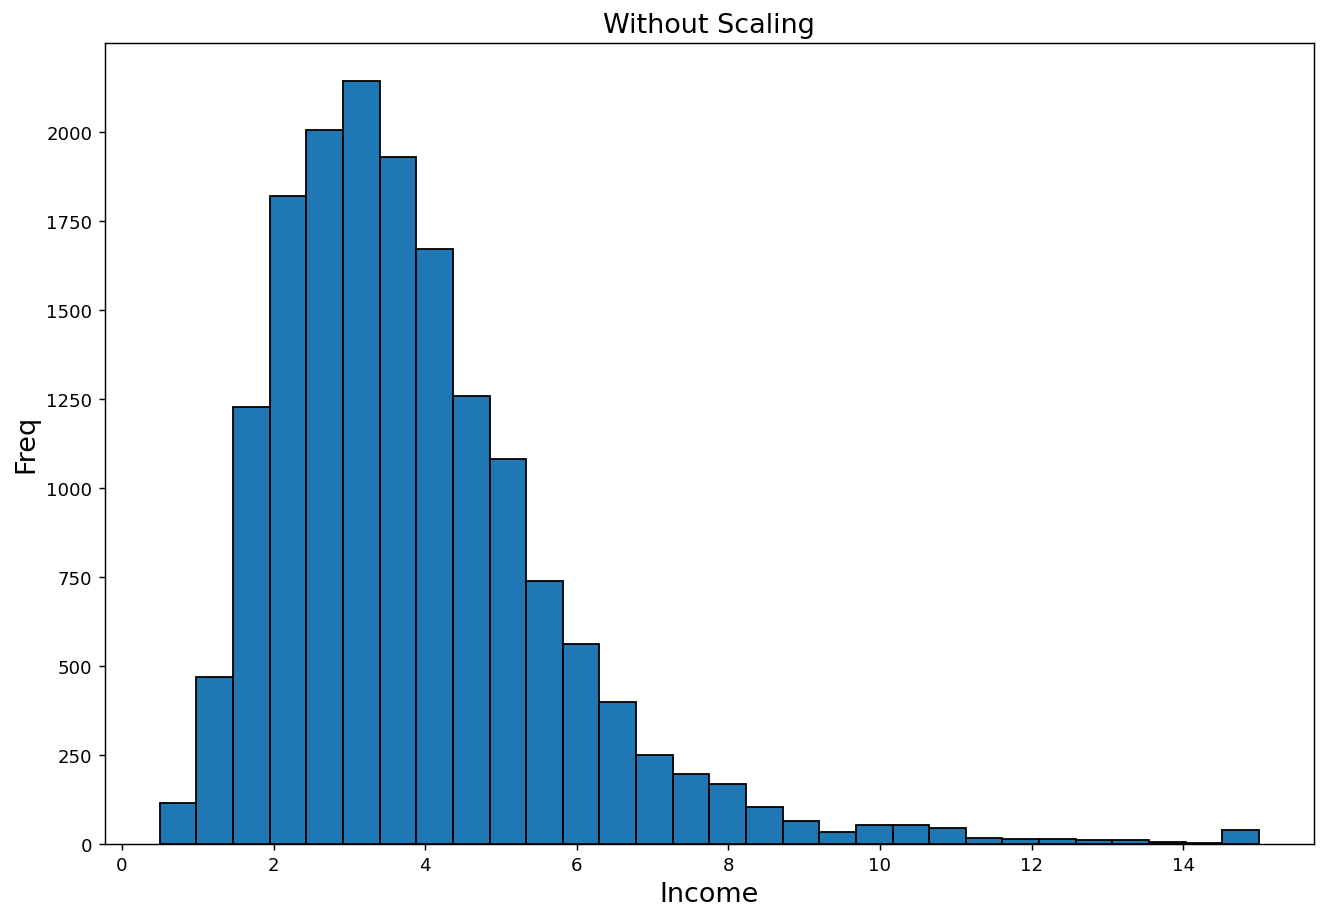

In [32]:
plt.figure(figsize=(12,8), dpi=130)
plt.title("Without Scaling", size=15)
plt.xlabel("Income", size=15)
plt.ylabel("Freq", size=15)
plt.hist(X_train_num_tr['median_income'], bins=30, ec='k')
plt.show()

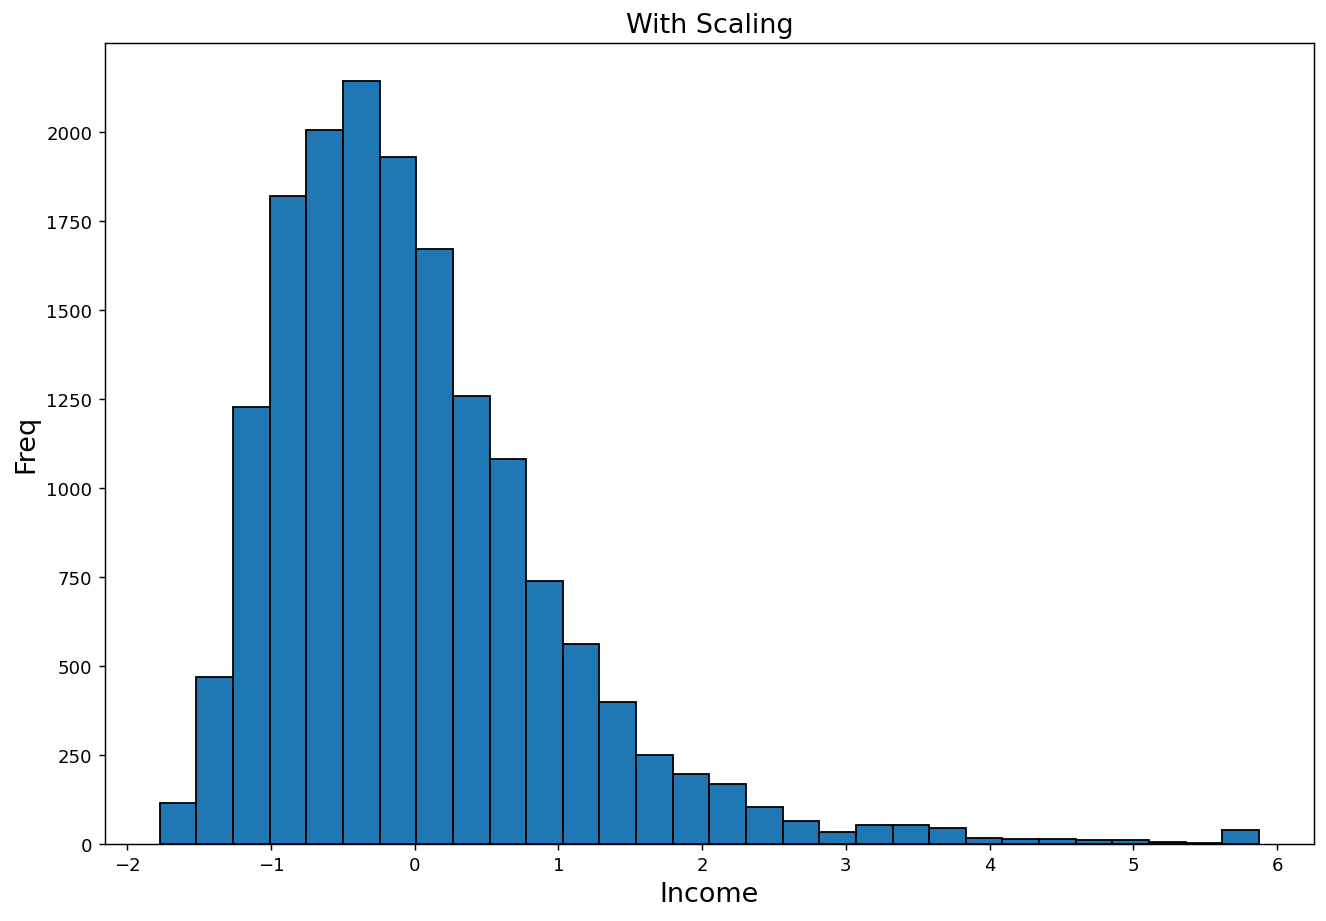

In [33]:
plt.figure(figsize=(12,8), dpi=130)
plt.title("With Scaling", size=15)
plt.xlabel("Income", size=15)
plt.ylabel("Freq", size=15)
plt.hist(X_train_num_tr_scale['median_income'], bins=30, ec='k')
plt.show()

### Handling the categorical columns (encoding)
1. Ordinal Encoding
2. One hot encoding

In [34]:
from sklearn.preprocessing import OrdinalEncoder

In [35]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
5800,-118.24,34.15,7.0,2063.0,670.0,1892.0,643.0,1.7301,<1H OCEAN
601,-122.08,37.70,25.0,3402.0,758.0,1645.0,710.0,3.4934,NEAR BAY
10379,-117.64,33.65,4.0,6842.0,1512.0,3256.0,1439.0,5.4132,<1H OCEAN
20405,-118.88,34.21,26.0,1590.0,196.0,654.0,199.0,6.5851,<1H OCEAN
7170,-118.19,34.06,37.0,1715.0,456.0,2052.0,440.0,2.3125,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
19198,-122.69,38.44,31.0,1808.0,315.0,691.0,280.0,3.8583,<1H OCEAN
3583,-118.55,34.23,25.0,4409.0,1018.0,4579.0,1010.0,2.8727,<1H OCEAN
18497,-121.54,36.99,27.0,2361.0,449.0,1782.0,397.0,3.2614,INLAND
4565,-118.26,34.07,40.0,680.0,273.0,995.0,249.0,2.2607,<1H OCEAN


In [36]:
X_train_cat = X_train.select_dtypes("object")
X_train_cat

,ocean_proximity
5800,<1H OCEAN
601,NEAR BAY
10379,<1H OCEAN
20405,<1H OCEAN
7170,<1H OCEAN
...,...
19198,<1H OCEAN
3583,<1H OCEAN
18497,INLAND
4565,<1H OCEAN


In [37]:
encoder = OrdinalEncoder()
encoder

,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [38]:
encoder.fit(X_train_cat)

,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [39]:
encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [40]:
encoder.transform(X_train_cat)

array([[0.],
       [3.],
       [0.],
       ...,
       [1.],
       [0.],
       [0.]], shape=(16512, 1))

In [41]:
X_train_cat

,ocean_proximity
5800,<1H OCEAN
601,NEAR BAY
10379,<1H OCEAN
20405,<1H OCEAN
7170,<1H OCEAN
...,...
19198,<1H OCEAN
3583,<1H OCEAN
18497,INLAND
4565,<1H OCEAN


In [42]:
from sklearn.preprocessing import OneHotEncoder

In [43]:
one_hot = OneHotEncoder()
one_hot

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [44]:
one_hot.fit(X_train_cat)

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [45]:
one_hot.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [46]:
sparse_matrix = one_hot.transform(X_train_cat)
sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [47]:
16512 * 5

82560

In [48]:
82560 - 16512

66048

In [49]:
one_hot.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [50]:
sparse_matrix.toarray()

array([[1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]], shape=(16512, 5))

In [51]:
one_hot.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [52]:
one_hot.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [53]:
pd.DataFrame(sparse_matrix.toarray(), columns=one_hot.get_feature_names_out())

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
16507,1.0,0.0,0.0,0.0,0.0
16508,1.0,0.0,0.0,0.0,0.0
16509,0.0,1.0,0.0,0.0,0.0
16510,1.0,0.0,0.0,0.0,0.0


### Pipelines

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer # use for combining multiple preprocessing steps for different types of features (numerical and categorical) into a single pipeline. This allows for more efficient and organized preprocessing of the dataset before feeding it into a machine learning model. 

In [56]:
house = pd.read_csv("Housing.csv")
X = house.drop('median_house_value', axis=1)
y = house.median_house_value

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=121)

In [57]:
num_cols = X.select_dtypes('float').columns
cat_cols = X.select_dtypes('object').columns

In [58]:
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
num_pipeline

,steps,"[('impute', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [59]:
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])
cat_pipeline

,steps,"[('impute', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [60]:
final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipeline, num_cols),
    ('cat_pipeline', cat_pipeline, cat_cols)
])
final_pipeline

,transformers,"[('num_pipeline', ...), ('cat_pipeline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [61]:
final_pipeline.fit(X_train)

,transformers,"[('num_pipeline', ...), ('cat_pipeline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [62]:
X_train_tr = final_pipeline.transform(X_train)
X_train_tr

array([[ 0.66136173, -0.69064867, -1.71479173, ...,  0.38008101,
        -1.12465992,  0.        ],
       [-1.25933122,  0.97054898, -0.28418936, ...,  0.55678574,
        -0.19477467,  3.        ],
       [ 0.96147001, -0.92462017, -1.95322546, ...,  2.47943863,
         0.81764165,  0.        ],
       ...,
       [-0.98923378,  0.63830945, -0.12523354, ..., -0.26871543,
        -0.31712105,  1.        ],
       [ 0.65135812, -0.72808411,  0.90797928, ..., -0.65904826,
        -0.8448453 ,  0.        ],
       [ 0.77640324, -0.85910815,  0.11320019, ..., -0.2739902 ,
         0.83029817,  0.        ]], shape=(16512, 9))

In [63]:
X_train_tr = pd.DataFrame(X_train_tr, columns=final_pipeline.get_feature_names_out())
X_train_tr

,num_pipeline__longitude,num_pipeline__latitude,num_pipeline__housing_median_age,num_pipeline__total_rooms,num_pipeline__total_bedrooms,num_pipeline__population,num_pipeline__households,num_pipeline__median_income,cat_pipeline__ocean_proximity
0,0.661362,-0.690649,-1.714792,-0.262430,0.321892,0.412041,0.380081,-1.124660,0.0
1,-1.259331,0.970549,-0.284189,0.354582,0.533365,0.194575,0.556786,-0.194775,3.0
2,0.961470,-0.924620,-1.953225,1.939735,2.345307,1.612946,2.479439,0.817642,0.0
3,0.341246,-0.662572,-0.204711,-0.480389,-0.817180,-0.677931,-0.790917,1.435649,0.0
4,0.686371,-0.732764,0.669546,-0.422789,-0.192372,0.552909,-0.155308,-0.817528,0.0
...,...,...,...,...,...,...,...,...,...
16507,-1.564441,1.316827,0.192678,-0.379934,-0.531210,-0.645355,-0.577289,-0.002343,0.0
16508,0.506306,-0.653213,-0.284189,0.818608,1.158173,2.777754,1.348001,-0.522104,0.0
16509,-0.989234,0.638309,-0.125234,-0.125112,-0.209194,0.315193,-0.268715,-0.317121,1.0
16510,0.651358,-0.728084,0.907979,-0.899717,-0.632141,-0.377704,-0.659048,-0.844845,0.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score


house = pd.read_csv("housing.csv")
X = house.drop('median_house_value', axis=1)
y = house.median_house_value

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=121)


num_cols = X.select_dtypes('float').columns
cat_cols = X.select_dtypes('object').columns


num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipeline, num_cols),
    ('cat_pipeline', cat_pipeline, cat_cols)
])

final_pipeline.fit(X_train)
X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)


linear = LinearRegression()
linear.fit(X_train_tr, y_train) # Fitting the linear regression model on the transformed training dataset
y_train_pred = linear.predict(X_train_tr)

y_test_pred = linear.predict(X_test_tr)

print(f"Training Report")
print(f"Training Error: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Training Accuracy: {r2_score(y_train,y_train_pred):.2f}")

print("Test Report")
print(f"Testing Error: {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"Testing Accuracy: {r2_score(y_test,y_test_pred):.2f}")

Training Report
Training Error: 51280.65
Training Accuracy: 0.63
Test Report
Testing Error: 49791.53
Testing Accuracy: 0.66


In [65]:
X_train_tr

array([[ 0.66136173, -0.69064867, -1.71479173, ...,  0.38008101,
        -1.12465992,  0.        ],
       [-1.25933122,  0.97054898, -0.28418936, ...,  0.55678574,
        -0.19477467,  3.        ],
       [ 0.96147001, -0.92462017, -1.95322546, ...,  2.47943863,
         0.81764165,  0.        ],
       ...,
       [-0.98923378,  0.63830945, -0.12523354, ..., -0.26871543,
        -0.31712105,  1.        ],
       [ 0.65135812, -0.72808411,  0.90797928, ..., -0.65904826,
        -0.8448453 ,  0.        ],
       [ 0.77640324, -0.85910815,  0.11320019, ..., -0.2739902 ,
         0.83029817,  0.        ]], shape=(16512, 9))

In [66]:
y_train

5800     202300.0
601      209900.0
10379    216600.0
20405    300000.0
7170     116100.0
           ...   
19198    193200.0
3583     245100.0
18497    305000.0
4565     165600.0
11586    223200.0
Name: median_house_value, Length: 16512, dtype: float64

In [67]:
y_train_pred

array([111027.56383104, 226860.51828378, 294689.55770921, ...,
       180294.63214056, 155825.94039354, 271139.55934712], shape=(16512,))

In [68]:
X_test_tr

array([[-1.4493998 ,  0.94715183, -0.99949055, ...,  2.83548546,
         0.49933011,  4.        ],
       [-1.27433664,  0.84420437,  0.51058973, ...,  0.14271646,
         1.81951086,  3.        ],
       [-1.3443619 ,  1.00330499,  1.8617142 , ..., -0.142121  ,
        -0.31337683,  3.        ],
       ...,
       [ 0.82642128, -0.84506986,  0.03372228, ..., -0.60102581,
        -0.77966421,  0.        ],
       [ 0.1861903 , -0.68128981,  0.51058973, ...,  0.55151097,
         0.20859924,  4.        ],
       [ 0.83142309, -0.77019898, -0.68157891, ...,  4.37835506,
        -0.32155084,  0.        ]], shape=(4128, 9))

In [69]:
y_test

16818    262000.0
18306    463700.0
549      254200.0
4239     434400.0
6084     188300.0
           ...   
6460     272600.0
18375    362700.0
11212    182900.0
20291    187300.0
6340     186700.0
Name: median_house_value, Length: 4128, dtype: float64

In [70]:
y_test_pred

array([254952.76800033, 375475.36444271, 246715.87710744, ...,
       143126.57756008, 226807.46555052, 168728.70753213], shape=(4128,))